In [ ]:
!pip install ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.4 MB/s eta 0:00:00


In [ ]:
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import imagehash
from PIL import Image
import cv2
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
hashes = {}
duplicates = []

for root, dirs, files in os.walk("/content/drive/My Drive/tomato-dataset/Data"):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            h = imagehash.phash(img)

            for existing_hash in hashes:
                if abs(h - existing_hash) < 5:  # seuil similarité
                    duplicates.append((path, hashes[existing_hash]))
                    break
            else:
                hashes[h] = path

        except:
            continue

print("Similar duplicates found:", len(duplicates))
# -----------------------------
# Vérification et suppression
# -----------------------------
for dup, original in duplicates:
    print("Original:", original)
    img1 = Image.open(original)
    img1.thumbnail((200, 200))  # miniatures pour affichage rapide
    display(img1)

    print("Duplicate:", dup)
    img2 = Image.open(dup)
    img2.thumbnail((200, 200))
    display(img2)

    # Demande confirmation
    choice = input("Do you want to delete the duplicate? (y/n): ").lower()
    if choice == 'y':
        os.remove(dup)
        print("Deleted \n")
    else:
        print("Skipped \n")

print("All duplicates processed!")

Similar duplicates found: 0
All duplicates processed!


In [ ]:
def is_blurry(image_path, threshold=50):
    image = cv2.imread(image_path)

    if image is None:
        print("Impossible de lire :", image_path)
        return False  # on ignore cette image

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    return laplacian_var < threshold

dataset_path = "/content/drive/My Drive/tomato-dataset/Data"

blurry_count = 0
processed_count = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        image_path = os.path.join(root, file)
        processed_count += 1

        if is_blurry(image_path):
            print("Blurry:", image_path)
            blurry_count += 1
            os.remove(image_path)
            print("Deleted:", image_path)


# 🔹 Messages finaux
if processed_count == 0:
    print("Aucun fichier trouvé dans le dataset.")
elif blurry_count == 0:
    print("Aucune image floue détectée")
else:
    print(f"\nTotal images traitées : {processed_count}")
    print(f"Images floues détectées : {blurry_count}")

⚠ Impossible de lire : /content/drive/My Drive/tomato-dataset/Data/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c
Aucune image floue détectée ✅


In [ ]:
# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])

# Load dataset
full_dataset = datasets.ImageFolder(root="/content/drive/My Drive/tomato-dataset/Data", transform=transform)

#split data to train and validation parts
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, num_workers=4, pin_memory=True, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=4, pin_memory=True, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Print class mapping
num_classes = len(full_dataset.classes)
print("Class to index mapping:")
print(full_dataset.class_to_idx)

Class to index mapping:
{'Tomato_Bacterial_spot': 0, 'Tomato_Early_blight': 1, 'Tomato_Late_blight': 2, 'Tomato_Leaf_Mold': 3, 'Tomato_Septoria_leaf_spot': 4, 'Tomato_Spider_mites_Two_spotted_spider_mite': 5, 'Tomato__Target_Spot': 6, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 7, 'Tomato__Tomato_mosaic_virus': 8, 'Tomato_healthy': 9}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
all_labels = full_dataset.targets  # already stored labels
class_counts = torch.bincount(torch.tensor(all_labels))

print("\nSamples per class:")
for class_name, class_index in full_dataset.class_to_idx.items():
    print(f"{class_name}: {class_counts[class_index].item()}")


Samples per class:
Tomato_Bacterial_spot: 2121
Tomato_Early_blight: 1000
Tomato_Late_blight: 1899
Tomato_Leaf_Mold: 950
Tomato_Septoria_leaf_spot: 1770
Tomato_Spider_mites_Two_spotted_spider_mite: 1670
Tomato__Target_Spot: 1404
Tomato__Tomato_YellowLeaf__Curl_Virus: 2954
Tomato__Tomato_mosaic_virus: 372
Tomato_healthy: 1578


In [ ]:
# number of samples per class
class_counts = [2121, 1000, 1899, 950, 1770, 1670, 1404, 2954, 372, 1578]

# compute weights: inverse of frequency
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
weights = weights / weights.sum()  # optional normalization

# loss with weights
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

In [ ]:
# 5. Load Pretrained ResNet
# -----------------------------
model = models.resnet18(pretrained=True)

# Freeze all layers except final classifier
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# -----------------------------

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


In [ ]:
# 7. Training Loop
# -----------------------------
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(outputs.argmax(1) == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    # Validation
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_corrects += torch.sum(outputs.argmax(1) == labels.data)
    val_acc = val_corrects.double() / len(val_dataset)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss: 1.0764 | Train Acc: 0.7105 | Val Acc: 0.8332
Epoch 2/10 | Train Loss: 0.6030 | Train Acc: 0.8311 | Val Acc: 0.8549
Epoch 3/10 | Train Loss: 0.4946 | Train Acc: 0.8608 | Val Acc: 0.8771
Epoch 4/10 | Train Loss: 0.4557 | Train Acc: 0.8630 | Val Acc: 0.8778
Epoch 5/10 | Train Loss: 0.4210 | Train Acc: 0.8703 | Val Acc: 0.8733
Epoch 6/10 | Train Loss: 0.3943 | Train Acc: 0.8814 | Val Acc: 0.8854
Epoch 7/10 | Train Loss: 0.3987 | Train Acc: 0.8779 | Val Acc: 0.8905
Epoch 8/10 | Train Loss: 0.3732 | Train Acc: 0.8831 | Val Acc: 0.8810
Epoch 9/10 | Train Loss: 0.3589 | Train Acc: 0.8899 | Val Acc: 0.8880
Epoch 10/10 | Train Loss: 0.3686 | Train Acc: 0.8841 | Val Acc: 0.8988


In [ ]:
# Make sure your model is in evaluation mode
model.eval()

# Track total correct predictions
total = 0
correct = 0

# Optional: store predictions for inspection
all_preds = []
all_labels = []

with torch.no_grad():  # no gradients needed for testing
    for images, labels in test_loader:  # your test DataLoader
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # Get predicted class index
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute accuracy
test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# Map predicted indices to class names
idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}
predicted_class_names = [idx_to_class[idx] for idx in all_preds]

# Optional: inspect first 10 predictions
print("First 10 predictions:")
for i in range(10):
    print(f"Predicted: {predicted_class_names[i]}, True: {idx_to_class[all_labels[i]]}")

Test Accuracy: 90.53%
First 10 predictions:
Predicted: Tomato__Target_Spot, True: Tomato__Target_Spot
Predicted: Tomato_Leaf_Mold, True: Tomato_Leaf_Mold
Predicted: Tomato_healthy, True: Tomato_Spider_mites_Two_spotted_spider_mite
Predicted: Tomato_Leaf_Mold, True: Tomato_Leaf_Mold
Predicted: Tomato__Tomato_YellowLeaf__Curl_Virus, True: Tomato__Tomato_YellowLeaf__Curl_Virus
Predicted: Tomato__Tomato_YellowLeaf__Curl_Virus, True: Tomato__Tomato_YellowLeaf__Curl_Virus
Predicted: Tomato_Septoria_leaf_spot, True: Tomato_Septoria_leaf_spot
Predicted: Tomato_Leaf_Mold, True: Tomato_Septoria_leaf_spot
Predicted: Tomato__Tomato_YellowLeaf__Curl_Virus, True: Tomato__Tomato_YellowLeaf__Curl_Virus
Predicted: Tomato_Leaf_Mold, True: Tomato_Leaf_Mold


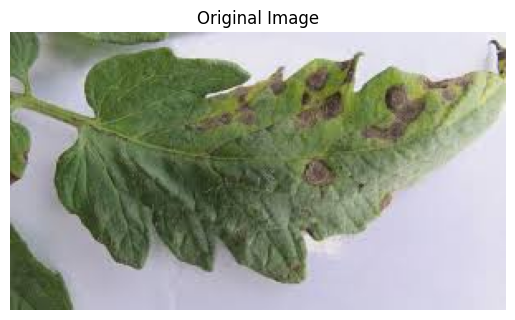

In [ ]:
image_path = "/content/target-spot.jpg"
image = Image.open(image_path).convert("RGB")

# Afficher image originale
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

image = transform(image)
image = image.unsqueeze(0)  # add batch dimension
image = image.to(device)


In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(image)
    _, predicted = torch.max(outputs, 1)

# Reverse mapping
idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}

predicted_class_name = idx_to_class[predicted.item()]

print("Predicted disease:", predicted_class_name)

Predicted disease: Tomato_Septoria_leaf_spot


In [ ]:
torch.save(model.state_dict(), "model.pth")